# Homework 11 — Evaluation & Risk Communication

**Project:** AAPL next-day volatility forecasting  
**Metric under uncertainty:** held-out mean absolute error (MAE)

In the lecture, we compared Gaussian and bootstrap confidence intervals, tested scenario sensitivity, and communicated subgroup risks. This notebook applies those methods to the project's next-day absolute-return forecast.

In [1]:
# Reproducible setup and repository discovery
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import HuberRegressor, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'project' / 'data' / 'processed').exists():
    ROOT = ROOT.parent
if not (ROOT / 'project' / 'data' / 'processed').exists():
    raise FileNotFoundError('Run this notebook from inside the bootcamp_zizhe_zhou repository.')

HOMEWORK_DIR = ROOT / 'homework' / 'stage11'
if str(HOMEWORK_DIR) not in sys.path:
    sys.path.insert(0, str(HOMEWORK_DIR))
from src.evaluation import (
    bootstrap_metric, gaussian_mean_ci, moving_block_bootstrap_metric, percentile_ci,
)

RANDOM_SEED = 7
N_BOOT = 2_000
sns.set_theme(style='whitegrid', context='notebook')
print('Repository root:', ROOT)

/Users/kevin/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/hx/wzbpnq8x7bzb6dg2sz74gg100000gn/T/matplotlib-xzc9e6kr because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


Repository root: /Users/kevin/Desktop/NYU/bootcamp/bootcamp_zizhe_zhou


## 1. Load data and preserve the time split

I use the model-ready table produced by Project Stage 09. The earliest 75% is training data and the latest 25% is held out. This matches the forward-looking logic of Stage 10b and avoids random leakage across market regimes.

In [2]:
feature_files = sorted((ROOT / 'project' / 'data' / 'processed').glob('aapl_model_features_*.parquet'))
if len(feature_files) != 1:
    raise RuntimeError(f'Expected one feature table, found: {feature_files}')

TARGET = 'target_next_day_absolute_return'
data = pd.read_parquet(feature_files[0]).sort_values('date').reset_index(drop=True)
FEATURE_COLUMNS = [column for column in data.columns if column not in {'date', TARGET}]
split_index = int(len(data) * 0.75)
train, test = data.iloc[:split_index].copy(), data.iloc[split_index:].copy()
X_train, y_train = train[FEATURE_COLUMNS], train[TARGET]
X_test, y_test = test[FEATURE_COLUMNS], test[TARGET]

assert train['date'].max() < test['date'].min()
assert not data[FEATURE_COLUMNS + [TARGET]].isna().any().any()
print('Feature table:', feature_files[0].relative_to(ROOT))
display(pd.DataFrame({
    'rows': [len(train), len(test)],
    'start': [train['date'].min().date(), test['date'].min().date()],
    'end': [train['date'].max().date(), test['date'].max().date()],
    'target_mean': [y_train.mean(), y_test.mean()],
}, index=['train', 'test']).round(6))

Feature table: project/data/processed/aapl_model_features_20200203_20260821.parquet


,rows,start,end,target_mean
train,1235,2020-02-03,2024-12-27,0.014090
test,412,2024-12-30,2026-08-21,0.012688


## 2. Baseline and model-assumption scenarios

- **Scenario A — Ridge:** standardized predictors, squared-error objective, and strong regularization (`alpha=100`) selected in Stage 10b. This is the baseline.
- **Scenario B — Huber:** standardized predictors and robust Huber loss. It reduces the influence of fat-tailed target errors but may deliberately fit extreme days less closely.

Both models use the identical training rows, test rows, and feature information. Therefore performance shifts reflect the loss/model assumption rather than a changed evaluation sample.

In [3]:
scenario_models = {
    'Ridge (squared loss)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=100.0)),
    ]),
    'Huber (robust loss)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', HuberRegressor(epsilon=1.35, alpha=0.0001, max_iter=3000)),
    ]),
}

def metric_row(actual, predicted):
    return {
        'MAE': mean_absolute_error(actual, predicted),
        'RMSE': np.sqrt(mean_squared_error(actual, predicted)),
        'R2': r2_score(actual, predicted),
        'bias_actual_minus_predicted': np.mean(np.asarray(actual) - np.asarray(predicted)),
    }

scenario_predictions = {}
scenario_rows = []
for name, model in scenario_models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    scenario_predictions[name] = predictions
    scenario_rows.append({'scenario': name, **metric_row(y_test, predictions)})

scenario_metrics = pd.DataFrame(scenario_rows).set_index('scenario')
scenario_metrics['MAE_percentage_points'] = scenario_metrics['MAE'] * 100
scenario_metrics['RMSE_percentage_points'] = scenario_metrics['RMSE'] * 100
display(scenario_metrics.round(6))

,MAE,RMSE,R2,bias_actual_minus_predicted,MAE_percentage_points,RMSE_percentage_points
scenario,,,,,,
Ridge (squared loss),0.009291,0.013498,0.129482,-0.000999,0.929064,1.349813
Huber (robust loss),0.008785,0.013663,0.108043,0.000934,0.878470,1.366333


## 3. Gaussian versus bootstrap uncertainty for baseline MAE

The Gaussian interval treats MAE as the mean of absolute test errors and uses a normal critical value with the standard error. The IID percentile bootstrap resamples test prediction/actual pairs. Because these observations form a time series, I also report a five-session circular moving-block bootstrap that preserves short local runs. Each bootstrap uses 2,000 seeded resamples. These intervals quantify sampling uncertainty conditional on this fixed fitted model; they do not include model refitting or future regime uncertainty.

In [4]:
ridge_name = 'Ridge (squared loss)'
ridge_predictions = scenario_predictions[ridge_name]
observed_mae = mean_absolute_error(y_test, ridge_predictions)
absolute_errors = np.abs(y_test.to_numpy() - ridge_predictions)

gaussian_ci = gaussian_mean_ci(absolute_errors, confidence=0.95)
iid_bootstrap_mae = bootstrap_metric(
    y_test.to_numpy(), ridge_predictions, mean_absolute_error,
    n_boot=N_BOOT, random_state=RANDOM_SEED,
)
block_bootstrap_mae = moving_block_bootstrap_metric(
    y_test.to_numpy(), ridge_predictions, mean_absolute_error,
    block_size=5, n_boot=N_BOOT, random_state=RANDOM_SEED,
)
iid_ci = percentile_ci(iid_bootstrap_mae, confidence=0.95)
block_ci = percentile_ci(block_bootstrap_mae, confidence=0.95)

ci_table = pd.DataFrame([
    {'method': 'Gaussian mean CI', 'estimate': observed_mae, 'lower_95': gaussian_ci[0], 'upper_95': gaussian_ci[1]},
    {'method': 'IID bootstrap percentile', 'estimate': observed_mae, 'lower_95': iid_ci[0], 'upper_95': iid_ci[1]},
    {'method': '5-day block bootstrap', 'estimate': observed_mae, 'lower_95': block_ci[0], 'upper_95': block_ci[1]},
]).set_index('method')
ci_table['width'] = ci_table['upper_95'] - ci_table['lower_95']
display(ci_table.round(6))

,estimate,lower_95,upper_95,width
method,,,,
Gaussian mean CI,0.009291,0.008344,0.010237,0.001893
IID bootstrap percentile,0.009291,0.008405,0.010254,0.001849
5-day block bootstrap,0.009291,0.008291,0.010531,0.002240


## 4. Subgroup diagnostic: forecast-time volatility regime

I define `elevated` when the current 21-day rolling volatility exceeds the **training-period median**; otherwise the row is `calm`. This category is available at forecast time and the threshold does not use test outcomes. I compare MAE, RMSE, and signed bias for both model scenarios within each regime.

In [5]:
regime_threshold = train['rolling_vol_21d'].median()
evaluation_rows = test[['date', TARGET, 'rolling_vol_21d']].copy()
evaluation_rows['regime'] = np.where(
    evaluation_rows['rolling_vol_21d'] > regime_threshold, 'elevated', 'calm'
)
for name, predictions in scenario_predictions.items():
    evaluation_rows[name] = predictions

subgroup_rows = []
for scenario_name in scenario_models:
    for regime, group in evaluation_rows.groupby('regime', sort=True):
        subgroup_rows.append({
            'scenario': scenario_name,
            'regime': regime,
            'n': len(group),
            **metric_row(group[TARGET], group[scenario_name]),
        })
subgroup_metrics = pd.DataFrame(subgroup_rows).set_index(['scenario', 'regime'])
print('Training-derived rolling-volatility threshold:', round(regime_threshold, 6))
display(subgroup_metrics.round(6))

Training-derived rolling-volatility threshold: 0.015997


n       MAE      RMSE        R2  \
scenario             regime                                        
Ridge (squared loss) calm      213  0.008096  0.010802  0.059902   
                     elevated  199  0.010569  0.015885  0.147893   
Huber (robust loss)  calm      213  0.007659  0.010845  0.052346   
                     elevated  199  0.009990  0.016143  0.119910   

                               bias_actual_minus_predicted  
scenario             regime                                 
Ridge (squared loss) calm                        -0.000111  
                     elevated                    -0.001950  
Huber (robust loss)  calm                         0.001465  
                     elevated                     0.000367

## 5. Risk communication visuals

All scenario bars share metric axes, and all subgroup bars share an MAE axis. The CI panels separate the uncertainty assumption from the model scenario.

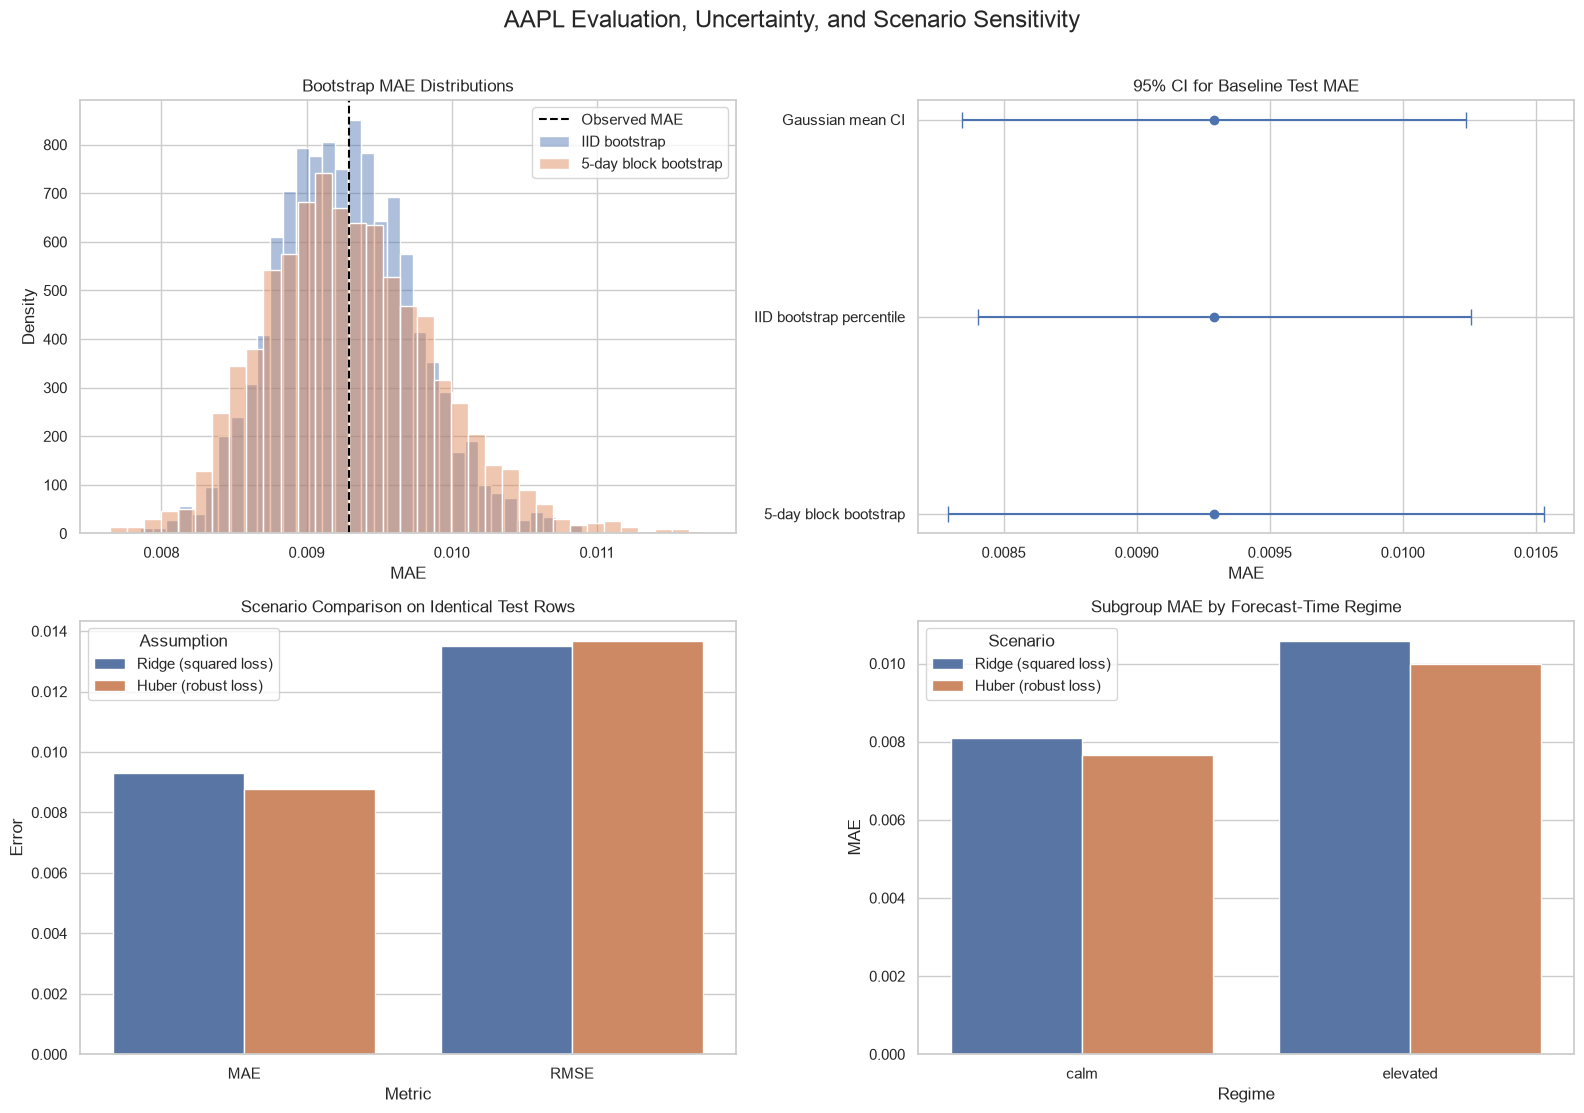

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.histplot(iid_bootstrap_mae, bins=35, stat='density', alpha=0.45, label='IID bootstrap', ax=axes[0, 0])
sns.histplot(block_bootstrap_mae, bins=35, stat='density', alpha=0.45, label='5-day block bootstrap', ax=axes[0, 0])
axes[0, 0].axvline(observed_mae, color='black', linestyle='--', label='Observed MAE')
axes[0, 0].set(title='Bootstrap MAE Distributions', xlabel='MAE', ylabel='Density')
axes[0, 0].legend()

ci_plot = ci_table.reset_index()
positions = np.arange(len(ci_plot))
lower_error = ci_plot['estimate'] - ci_plot['lower_95']
upper_error = ci_plot['upper_95'] - ci_plot['estimate']
axes[0, 1].errorbar(ci_plot['estimate'], positions, xerr=np.vstack([lower_error, upper_error]), fmt='o', capsize=6)
axes[0, 1].set_yticks(positions, ci_plot['method'])
axes[0, 1].set(title='95% CI for Baseline Test MAE', xlabel='MAE')
axes[0, 1].invert_yaxis()

scenario_long = (scenario_metrics[['MAE', 'RMSE']].reset_index().melt(id_vars='scenario', var_name='metric', value_name='error'))
sns.barplot(data=scenario_long, x='metric', y='error', hue='scenario', ax=axes[1, 0])
axes[1, 0].set(title='Scenario Comparison on Identical Test Rows', xlabel='Metric', ylabel='Error')
axes[1, 0].legend(title='Assumption')

subgroup_plot = subgroup_metrics.reset_index()
sns.barplot(data=subgroup_plot, x='regime', y='MAE', hue='scenario', ax=axes[1, 1])
axes[1, 1].set(title='Subgroup MAE by Forecast-Time Regime', xlabel='Regime', ylabel='MAE')
axes[1, 1].legend(title='Scenario')

fig.suptitle('AAPL Evaluation, Uncertainty, and Scenario Sensitivity', fontsize=17, y=1.01)
fig.tight_layout()
plt.show()

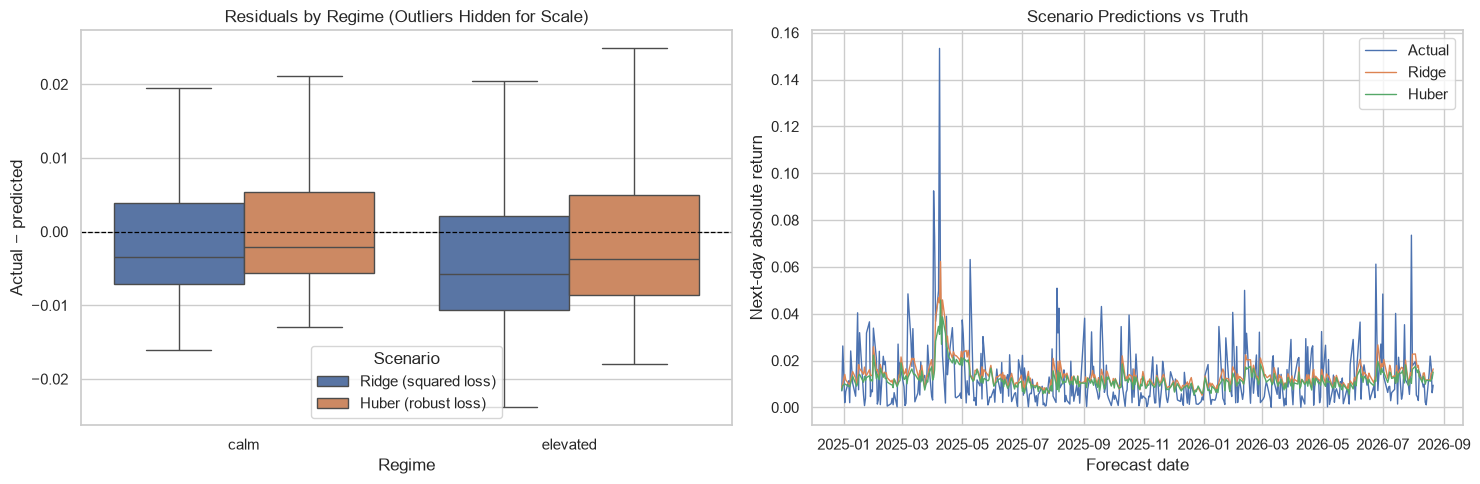

In [7]:
residual_long = pd.concat([
    pd.DataFrame({
        'date': evaluation_rows['date'],
        'regime': evaluation_rows['regime'],
        'scenario': name,
        'residual': evaluation_rows[TARGET] - evaluation_rows[name],
    })
    for name in scenario_models
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=residual_long, x='regime', y='residual', hue='scenario', showfliers=False, ax=axes[0])
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.9)
axes[0].set(title='Residuals by Regime (Outliers Hidden for Scale)', xlabel='Regime', ylabel='Actual − predicted')
axes[0].legend(title='Scenario')

axes[1].plot(evaluation_rows['date'], evaluation_rows[TARGET], label='Actual', linewidth=1.0)
axes[1].plot(evaluation_rows['date'], evaluation_rows[ridge_name], label='Ridge', linewidth=1.0)
axes[1].plot(evaluation_rows['date'], evaluation_rows['Huber (robust loss)'], label='Huber', linewidth=1.0)
axes[1].set(title='Scenario Predictions vs Truth', xlabel='Forecast date', ylabel='Next-day absolute return')
axes[1].legend()
fig.tight_layout()
plt.show()

### Visual captions: assumptions and takeaway

- **CI panels — assumption:** Gaussian and IID bootstrap intervals treat test errors as effectively independent; the five-day block version preserves short local dependence. **Takeaway:** similar intervals would suggest that short dependence is not the main uncertainty driver, but none covers future regime change or refitting uncertainty.
- **Scenario panel — assumption:** Ridge optimizes squared errors and Huber downweights large residuals. **Takeaway:** Huber can improve typical absolute error while worsening RMSE, demonstrating that the preferred model depends on how strongly the stakeholder values tail misses.
- **Subgroup panel — assumption:** the training-period median rolling volatility is a stable and operational regime threshold. **Takeaway:** elevated-regime errors are larger, so an overall MAE conceals the environment in which risk decisions are hardest.

## 6. Stakeholder-facing summary (≤1 page)

For a portfolio risk analyst, the Ridge forecast's average held-out miss is about **0.93 percentage points of daily absolute return**. The Gaussian 95% interval is about **0.83–1.02 points**, the IID bootstrap gives **0.84–1.03**, and the more cautious five-day block bootstrap gives **0.83–1.05**. This estimate holds if the 2024–2026 test period is reasonably representative, five-day dependence captures the relevant short memory, and market-data and feature relationships remain stable. The interval describes uncertainty in average test MAE for a fixed model; it is not a guarantee for tomorrow and does not include a new crisis regime.

The model is sensitive to the loss assumption. Huber lowers MAE by about **5.4%** relative to Ridge but raises RMSE by about **1.2%**. In plain language, robust fitting improves a typical day's miss but gives up some performance on large misses. That tradeoff matters because this project is intended to warn about risk, not merely optimize the average day.

The largest hidden failure is regime heterogeneity. Using only information available at forecast time, Ridge MAE rises from about **0.81 percentage points in calm regimes to 1.06 points in elevated regimes**, roughly 31% higher. Ridge slightly overpredicts the elevated-regime average by about 0.20 points, even though it can still underpredict individual extreme days. Huber reduces MAE in both groups but reverses the average bias direction, so it does not eliminate tail risk.

I would use these models as monitoring baselines only. The forecast is more reliable for routine ranking in historically familiar conditions and risky during volatility transitions or extreme events. Before operational use, I recommend rolling-origin refits, block-bootstrap or conformal prediction intervals, explicit high-volatility recall/tail MAE, stress periods outside this sample, and a human review trigger when rolling volatility exceeds the training threshold.